Librerias

In [ ]:
!pip install tensorflow scikit-learn matplotlib pandas

Importar librerias

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import matplotlib.pyplot as plt

Cargar CSV

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dirt_rally_multilabel_normalized.csv to dirt_rally_multilabel_normalized.csv


In [ ]:
df = pd.read_csv("dirt_rally_multilabel_normalized.csv")

print(df.head())
print(df.shape)

   R_x0  R_y0  R_z0      R_x1      R_y1      R_z1      R_x2      R_y2  \
0   0.0   0.0   0.0 -0.043697 -0.035654 -0.017445 -0.078539 -0.059673   
1   0.0   0.0   0.0 -0.022058 -0.059173 -0.019075 -0.052035 -0.094696   
2   0.0   0.0   0.0 -0.014912 -0.064964 -0.020961 -0.033498 -0.116025   
3   0.0   0.0   0.0 -0.009926 -0.052534 -0.027221 -0.032806 -0.087322   
4   0.0   0.0   0.0 -0.009103 -0.044583 -0.029610 -0.028703 -0.082500   

       R_z2      R_x3  ...     L_y18     L_z18     L_x19     L_y19     L_z19  \
0 -0.035569 -0.100596  ...  0.044162 -0.085637  0.108342  0.028147 -0.079398   
1 -0.038954 -0.087337  ...  0.025012 -0.047379  0.097433  0.013490 -0.038096   
2 -0.041284 -0.061379  ... -0.013770 -0.049146  0.101455 -0.036809 -0.033725   
3 -0.053682 -0.068230  ...  0.009670 -0.080419  0.083343 -0.000098 -0.069990   
4 -0.054539 -0.060497  ...  0.014556 -0.091307  0.083207  0.003127 -0.077500   

      L_x20     L_y20     L_z20  accelerate  brake  
0  0.102352  0.021188 -0.07

Separar Features y Labels

In [ ]:
# Features
X = df.drop(columns=["accelerate", "brake"]).values

# Labels
y = df[["accelerate", "brake"]].values

print(X.shape)
print(y.shape)

(18660, 126)
(18660, 2)


Train / Validation / Test Split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

Balance clases

In [ ]:
print(df["accelerate"].value_counts())
print(df["brake"].value_counts())

accelerate
1.0    9645
0.0    9015
Name: count, dtype: int64
brake
1.0    9636
0.0    9024
Name: count, dtype: int64


Creacion modelo

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(126,)
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        32,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        2,
        activation='sigmoid'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compilar modelo


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Entrenamiento modelo


In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=40,
    batch_size=32
)

Epoch 1/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.6844 - loss: 0.2978 - val_accuracy: 0.7249 - val_loss: 0.0306
Epoch 2/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7582 - loss: 0.0371 - val_accuracy: 0.6281 - val_loss: 0.0133
Epoch 3/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7559 - loss: 0.0227 - val_accuracy: 0.6549 - val_loss: 0.0114
Epoch 4/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7664 - loss: 0.0167 - val_accuracy: 0.7767 - val_loss: 0.0084
Epoch 5/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7703 - loss: 0.0132 - val_accuracy: 0.7839 - val_loss: 0.0061
Epoch 6/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7739 - loss: 0.0140 - val_accuracy: 0.6949 - val_loss: 0.0086
Epoch 7/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7745 - loss: 0.0116 - val_accuracy: 0.8339 - val_loss: 0.0065
Epoch 8/40
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7957 - loss: 0.0114 - val_accuracy: 0.

Graficar entrenamiento

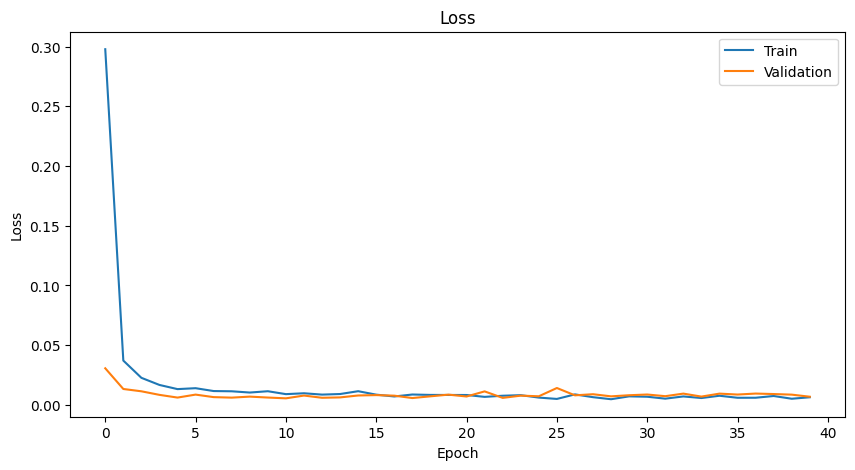

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

Accuracy

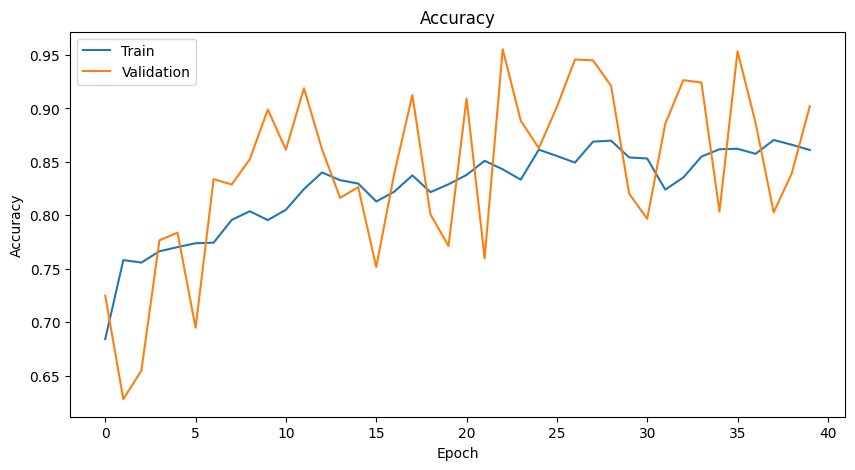

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

Evaluacion modelo


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"\nTest Accuracy: {accuracy:.4f}")

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9085 - loss: 0.0042

Test Accuracy: 0.9085


Predicciones

In [ ]:
y_pred_probs = model.predict(X_test)

# Convertir probabilidades a binarias
y_pred = (y_pred_probs > 0.5).astype(int)

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Reporte clasificacion

In [ ]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["accelerate", "brake"]
))


Classification Report:
              precision    recall  f1-score   support

  accelerate       1.00      1.00      1.00      1431
       brake       1.00      1.00      1.00      1443

   micro avg       1.00      1.00      1.00      2874
   macro avg       1.00      1.00      1.00      2874
weighted avg       1.00      1.00      1.00      2874
 samples avg       0.77      0.77      0.77      2874



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Matriz confusion

In [ ]:
cm_acc = confusion_matrix(
    y_test[:,0],
    y_pred[:,0]
)

print("Confusion Matrix - Accelerate")
print(cm_acc)

Confusion Matrix - Accelerate
[[1367    1]
 [   1 1430]]


In [ ]:
cm_brake = confusion_matrix(
    y_test[:,1],
    y_pred[:,1]
)

print("Confusion Matrix - Brake")
print(cm_brake)

Confusion Matrix - Brake
[[1354    2]
 [   2 1441]]


Mostrar matrices

Matriz confusion

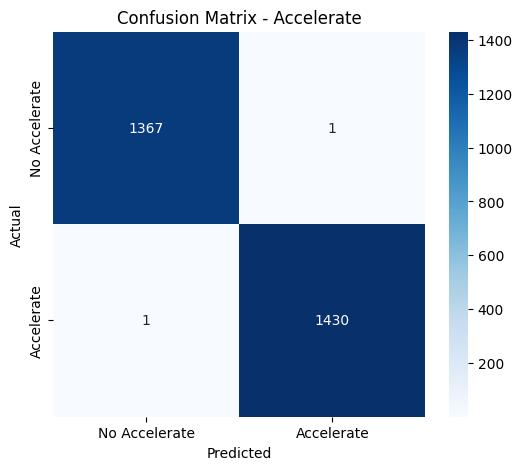

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_acc,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Accelerate", "Accelerate"],
    yticklabels=["No Accelerate", "Accelerate"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Accelerate")

plt.show()

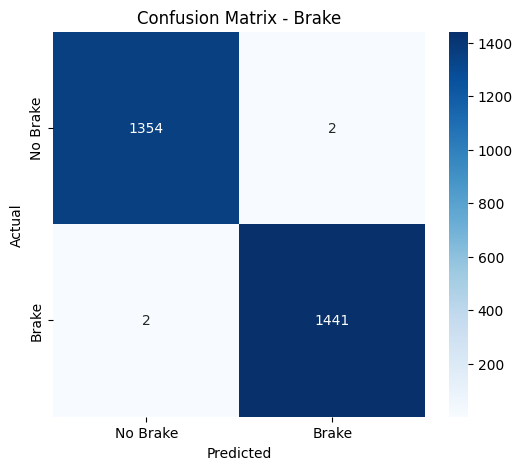

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_brake,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Brake", "Brake"],
    yticklabels=["No Brake", "Brake"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Brake")

plt.show()

Guardar modelo


In [ ]:
model.save("dirt_rally_model.keras")

In [ ]:
model.save("dirt_rally_model.h5")

print("Modelo guardado.")

Modelo guardado.


In [ ]:
model.save_weights("dirt_rally.weights.h5")


Descargar modelo

In [ ]:
from google.colab import files

files.download("dirt_rally_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("dirt_rally_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("dirt_rally.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>